In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow Version:", tf.__version__)

# 1. RTX 3050 Hardware Safeguards
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ VRAM Memory Growth Enabled.")
else:
    print("❌ GPU NOT DETECTED.")

# 2. Mixed Precision for 50% Memory Reduction
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed Precision (FP16) Activated.")

I0000 00:00:1780939984.021777  358180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780939984.476635  358180 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780939986.831385  358180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Version: 2.21.0
✅ VRAM Memory Growth Enabled.
✅ Mixed Precision (FP16) Activated.


In [2]:
# CELL 2: Data Parsing & 15,000 Image Sub-Sampling
IMAGE_DIR = "../data/images/" 
CSV_PATH = "Data_Entry_2017_v2020.csv"

print("Reading dataset metadata...")
df = pd.read_csv(CSV_PATH)
df = df[['Image Index', 'Finding Labels']]

# Align with your colleague's target of converting 'No Finding' to 'Normal'
df['Finding Labels'] = df['Finding Labels'].replace('No Finding', 'Normal')

# Strip out references to images that aren't inside your native directory folder
available_images = set(os.listdir(IMAGE_DIR))
df = df[df['Image Index'].isin(available_images)].reset_index(drop=True)
print(f"Total confirmed local files matched: {len(df)}")

# Define the master 15 classes in their exact structure
classes = ["Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass", 
           "Nodule", "Pneumonia", "Pneumothorax", "Consolidation", "Edema", 
           "Emphysema", "Fibrosis", "Pleural_Thickening", "Hernia", "Normal"]
label_map = {label: i for i, label in enumerate(classes)}

def encode_labels(label_string):
    vector = np.zeros(len(classes))
    for label in label_string.split('|'):
        if label in label_map:
            vector[label_map[label]] = 1
    return vector

df['encoded_labels'] = df['Finding Labels'].apply(encode_labels)

# SCALING UP TO 15,000 IMAGES FOR ENHANCED NETWORK TRAINING
SAMPLE_SIZE = 15000
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)
print(f"Dataset downsampled to high-accuracy threshold size: {len(df_sample)} arrays.")

image_paths = df_sample['Image Index'].apply(lambda x: os.path.join(IMAGE_DIR, x)).values
labels_matrix = np.stack(df_sample['encoded_labels'].values).astype('float32')

Reading dataset metadata...
Total confirmed local files matched: 24999
Dataset downsampled to high-accuracy threshold size: 15000 arrays.


  CLASS DISTRIBUTION (15000 IMAGE SAMPLE)
         Pathology  Image Count
            Normal         8825
      Infiltration         2191
          Effusion         1387
       Atelectasis         1334
            Nodule          732
      Pneumothorax          550
     Consolidation          540
              Mass          498
      Cardiomegaly          486
Pleural_Thickening          421
          Fibrosis          322
         Emphysema          277
             Edema          200
         Pneumonia          166
            Hernia           33
Total Label Allocations: 17962
Note: Total labels can exceed sample size due to multi-label cases.


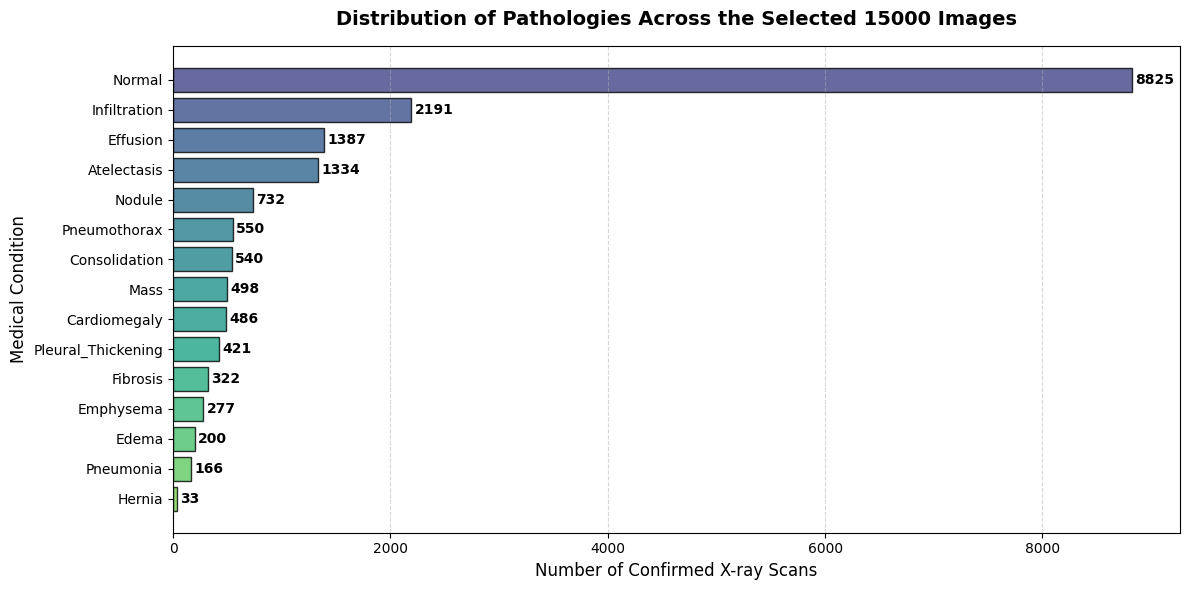

In [19]:
# CELL 2B: Calculate and Plot Class Distribution in the Sample
import pandas as pd
import matplotlib.pyplot as plt

# 1. Sum up the occurrences of each disease from the multi-hot encoded matrix
class_counts = labels_matrix.sum(axis=0).astype(int)

# 2. Build a clean summary DataFrame
distribution_df = pd.DataFrame({
    'Pathology': classes,
    'Image Count': class_counts
}).sort_values(by='Image Count', ascending=False).reset_index(drop=True)

# 3. Print out the text report
print("=" * 40)
print(f"  CLASS DISTRIBUTION ({len(df_sample)} IMAGE SAMPLE)")
print("=" * 40)
print(distribution_df.to_string(index=False))
print("=" * 40)
print(f"Total Label Allocations: {class_counts.sum()}")
print("Note: Total labels can exceed sample size due to multi-label cases.")

# 4. Generate a Notebook Bar Chart for your presentation/colleague
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(classes)))
bars = plt.barh(distribution_df['Pathology'], distribution_df['Image Count'], color=colors, edgecolor='black', alpha=0.8)

# Add value tags to the end of each horizontal bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 30, bar.get_y() + bar.get_height()/2, f'{int(width)}', 
             va='center', ha='left', fontsize=10, weight='bold')

plt.title(f'Distribution of Pathologies Across the Selected {len(df_sample)} Images', fontsize=14, weight='bold', pad=15)
plt.xlabel('Number of Confirmed X-ray Scans', fontsize=12)
plt.ylabel('Medical Condition', fontsize=12)
plt.gca().invert_yaxis()  # Put the most frequent condition at the top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
# CELL 3: Asynchronous CPU-to-GPU Pipeline Construction
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def parse_function(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0  # Min-max normalization
    return image, label

# Create dataset tensor slices
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels_matrix))
dataset = dataset.shuffle(buffer_size=2000, seed=42)

# Replicate the 80/20 train/validation distribution ratio
train_size = int(0.8 * len(df_sample))
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

# Apply parallel threaded prefetching to keep the RTX 3050 saturated
AUTOTUNE = tf.data.AUTOTUNE
train_pipeline = train_dataset.map(parse_function, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_pipeline = val_dataset.map(parse_function, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✅ Training and validation streams initialized and cached.")

I0000 00:00:1780940263.712150  358180 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


✅ Training and validation streams initialized and cached.


In [20]:
# TUNED CELL 4: ResNet50 with Dynamic Positional Class Weighting
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

# ============================================================
# 1. DYNAMICALLY CALCULATE POSITIONAL WEIGHTS
# ============================================================
total_samples = labels_matrix.shape[0]        # 15000
pos_counts = labels_matrix.sum(axis=0)        # Positive instances per class
neg_counts = total_samples - pos_counts       # Negative instances per class

# Safeguard against any potential zero counts
pos_counts = np.maximum(pos_counts, 1)

# Formula: pos_weight = negative_samples / positive_samples
# This scales up the penalty when missing a rare class
derived_pos_weights = neg_counts / pos_counts

print("=" * 50)
print("   CALCULATED PER-CLASS LOSS WEIGHT PENALTIES")
print("=" * 50)
for cls, weight in zip(classes, derived_pos_weights):
    print(f"{cls:<20} -> Multiplier: {weight:.2f}x")
print("=" * 50)

# ============================================================
# 2. DEFINE CUSTOM WEIGHTED LOSS CLASS
# ============================================================
class WeightedBinaryCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, pos_weights, name="weighted_binary_crossentropy"):
        super().__init__(name=name)
        # Convert array to tensor float32 for mixed precision matching
        self.pos_weights = tf.constant(pos_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        # Clip values to prevent log(0) numerical instability errors
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        # Weighted Binary Cross-Entropy Equation
        pos_loss = y_true * tf.math.log(y_pred) * self.pos_weights
        neg_loss = (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        
        # Compute mean loss across all 15 condition categories
        return -tf.reduce_mean(pos_loss + neg_loss, axis=-1)

# ============================================================
# 3. CONSTRUCT THE MODEL ARCHITECTURE (With 95 Trainable Layers)
# ============================================================
print("\nInitializing Backbone Architecture...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = True
for layer in base_model.layers[:-95]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'), 
    layers.Dropout(0.4),                 
    layers.Dense(15, activation='sigmoid', dtype='float32')  
])

# ============================================================
# 4. COMPILE USING CUSTOM WEIGHTED LOSS
# ============================================================
model.compile(
    optimizer=Adam(learning_rate=0.000002),
    loss=WeightedBinaryCrossEntropy(pos_weights=derived_pos_weights),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("✅ Imbalance-aware model compiled successfully.")

   CALCULATED PER-CLASS LOSS WEIGHT PENALTIES
Atelectasis          -> Multiplier: 10.24x
Cardiomegaly         -> Multiplier: 29.86x
Effusion             -> Multiplier: 9.81x
Infiltration         -> Multiplier: 5.85x
Mass                 -> Multiplier: 29.12x
Nodule               -> Multiplier: 19.49x
Pneumonia            -> Multiplier: 89.36x
Pneumothorax         -> Multiplier: 26.27x
Consolidation        -> Multiplier: 26.78x
Edema                -> Multiplier: 74.00x
Emphysema            -> Multiplier: 53.15x
Fibrosis             -> Multiplier: 45.58x
Pleural_Thickening   -> Multiplier: 34.63x
Hernia               -> Multiplier: 453.55x
Normal               -> Multiplier: 0.70x

Initializing Backbone Architecture...
✅ Imbalance-aware model compiled successfully.


In [21]:
# TUNED CELL 5: Active Training Run
os.makedirs('../models', exist_ok=True)

callbacks = [
    ModelCheckpoint(
        '../models/best_chest_xray_model.keras', 
        monitor='val_auc', 
        mode='max', 
        save_best_only=True, 
        verbose=1
    ),
    # Increased patience to 7 to allow the unfrozen weights to safely stabilize
    EarlyStopping(
        monitor='val_loss', 
        patience=7, 
        restore_best_weights=True, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-8, 
        verbose=1
    )
]

print(f"🚀 Launching Tuned Fine-Tuning Pass on {len(df_sample)} images...")
history = model.fit(
    train_pipeline, 
    validation_data=val_pipeline, 
    epochs=25, 
    callbacks=callbacks, 
    verbose=1
)
print("✅ Tuned optimization pass completed successfully!")

🚀 Launching Tuned Fine-Tuning Pass on 15000 images...
Epoch 1/25


I0000 00:00:1780949958.871634  359097 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_453226__.303


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.0416 - auc: 0.3646 - loss: 1.3395
Epoch 1: val_auc improved from None to 0.36090, saving model to ../models/best_chest_xray_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 146s 284ms/step - accuracy: 0.0422 - auc: 0.3873 - loss: 1.3157 - val_accuracy: 0.0447 - val_auc: 0.3609 - val_loss: 1.3252 - learning_rate: 2.0000e-06
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.0522 - auc: 0.4726 - loss: 1.2454
Epoch 2: val_auc improved from 0.36090 to 0.43586, saving model to ../models/best_chest_xray_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 98s 259ms/step - accuracy: 0.0547 - auc: 0.4858 - loss: 1.2469 - val_accuracy: 0.0457 - val_auc: 0.4359 - val_loss: 1.2378 - learning_rate: 2.0000e-06
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.0626 - auc: 0.5161 - loss: 1.2158
Epoch 3: val_auc improved from 0.43586 to 0.55831, saving model to ../models/best_chest_xray_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 95s

Evaluating final metrics against testing pipeline partitions...
-------------------------------------------------------
Overall Model Validation Loss:     1.0104
Overall Model Validation Accuracy: 0.3343
Overall Model Validation AUC:      0.7980
-------------------------------------------------------


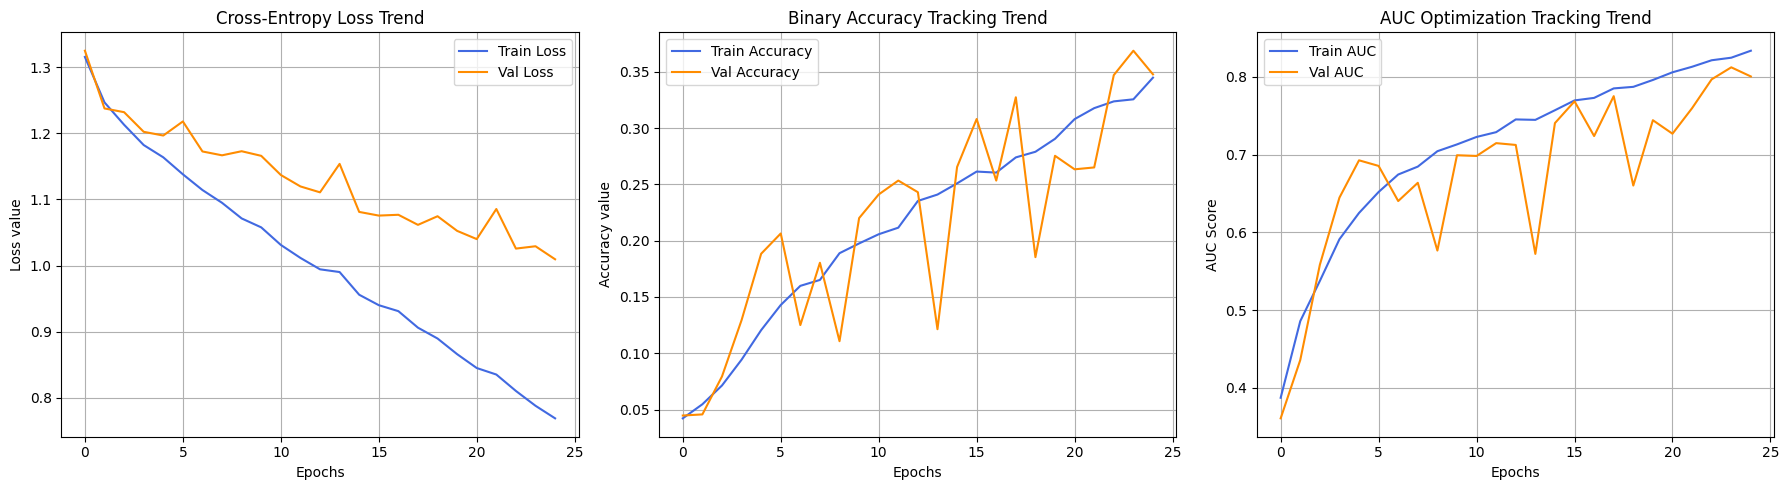

In [22]:
# CELL 6: Model Validation Metrics and Matplotlib Visualizations
print("Evaluating final metrics against testing pipeline partitions...")
loss, accuracy, auc = model.evaluate(val_pipeline, verbose=0)
print("-" * 55)
print(f"Overall Model Validation Loss:     {loss:.4f}")
print(f"Overall Model Validation Accuracy: {accuracy:.4f}")
print(f"Overall Model Validation AUC:      {auc:.4f}")
print("-" * 55)

# Build out side-by-side metric verification graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Metric Paths
axes[0].plot(history.history['loss'], label='Train Loss', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='darkorange')
axes[0].set_title('Cross-Entropy Loss Trend')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss value')
axes[0].legend()
axes[0].grid(True)

# 2. Accuracy Tracks
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='royalblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='darkorange')
axes[1].set_title('Binary Accuracy Tracking Trend')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy value')
axes[1].legend()
axes[1].grid(True)

# 3. Area Under Curve (AUC) Metrics
axes[2].plot(history.history['auc'], label='Train AUC', color='royalblue')
axes[2].plot(history.history['val_auc'], label='Val AUC', color='darkorange')
axes[2].set_title('AUC Optimization Tracking Trend')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('AUC Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()